# DeepLense GSoC 2026 — Common Test I: Multi-Class Gravitational Lens Classification

**Task:** Classify strong lensing images into 3 classes:
- `no` — No substructure
- `sphere` — Subhalo substructure  
- `vort` — Vortex substructure

**Strategy:** Fine-tune a pretrained **EfficientNet-B3** backbone with custom augmentation pipeline, label smoothing, and cosine annealing scheduler. EfficientNet-B3 offers the best accuracy/parameter tradeoff for small scientific image datasets.
**Evaluation:** ROC curve (per-class, one-vs-rest) + AUC score

## 1. Setup & Imports

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm import tqdm
import timm
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\kisho\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
DATA_ROOT   = './dataset'   
CLASS_NAMES = ['no', 'sphere', 'vort']
NUM_CLASSES = 3
IMG_SIZE    = 224          
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 3e-4
WEIGHT_DECAY= 1e-4
LABEL_SMOOTHING = 0.1
# ────────────────────────────────────────────────────────────────────────────

class LensDataset(Dataset):
    """
    Loads .npy images from disk.
    Each .npy file is a 2D (H, W) or 3D (C, H, W) float array,
    already min-max normalised to [0, 1].
    """
    def __init__(self, root, split='train', transform=None):
        self.transform = transform
        self.samples = []
        split_dir = Path(root) / split
        for label_idx, cls in enumerate(CLASS_NAMES):
            cls_dir = split_dir / cls
            files = sorted(cls_dir.glob('*.npy'))
            for f in files:
                self.samples.append((f, label_idx))
        print(f'[{split}] {len(self.samples)} samples loaded')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=0)         
        elif img.ndim == 3 and img.shape[0] == 1:
            img = np.repeat(img, 3, axis=0)                  
        elif img.ndim == 3 and img.shape[-1] in [1, 3]:
            img = img.transpose(2, 0, 1)                     
            if img.shape[0] == 1:
                img = np.repeat(img, 3, axis=0)

        img = torch.from_numpy(img)                          

        if self.transform:
            img = self.transform(img)

        return img, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=45),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = LensDataset(DATA_ROOT, split='train', transform=train_transform)
val_dataset   = LensDataset(DATA_ROOT, split='val',   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

[train] 30000 samples loaded
[val] 7500 samples loaded
Train batches: 938 | Val batches: 235


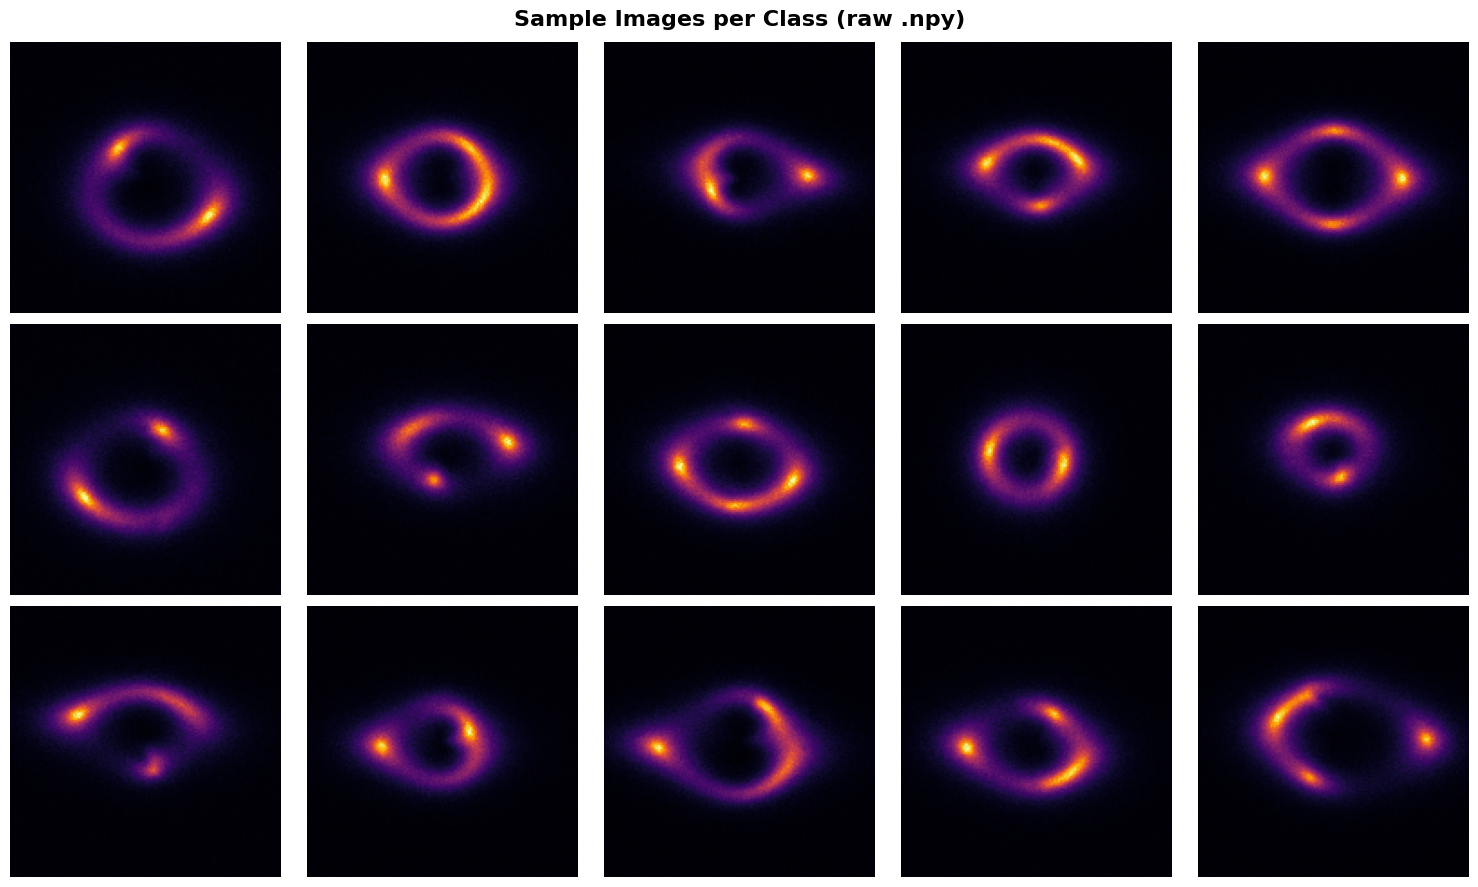

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images per Class (raw .npy)', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_files = sorted((Path(DATA_ROOT) / 'train' / cls).glob('*.npy'))[:5]
    for col, f in enumerate(cls_files):
        img = np.load(f).astype(np.float32)
        if img.ndim == 3:
            img = img[0] if img.shape[0] <= 3 else img[:, :, 0]
        axes[row, col].imshow(img, cmap='inferno', origin='lower')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=13, rotation=0,
                                      labelpad=50, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def build_model(model_name='efficientnet_b3', num_classes=NUM_CLASSES, pretrained=True):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    in_features = model.get_classifier().in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model


model = build_model().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Total params:     10,700,843
Trainable params: 10,700,843


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Training', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    pbar = tqdm(loader, desc='Evaluating', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return total_loss / total, correct / total, all_probs, all_labels


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = 'best_model.pth'

print(f'{"Epoch":>6} {"Train Loss":>12} {"Train Acc":>10} {"Val Loss":>10} {"Val Acc":>9} {"LR":>12}')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6} {tr_loss:>12.4f} {tr_acc:>10.4f} {vl_loss:>10.4f} {vl_acc:>9.4f} {current_lr:>12.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val_acc={vl_acc:.4f})')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

 Epoch   Train Loss  Train Acc   Val Loss   Val Acc           LR
----------------------------------------------------------------------


     1       0.8675     0.6160     0.6369    0.8052     2.93e-04
  ✓ Best model saved (val_acc=0.8052)


     2       0.5815     0.8389     0.5607    0.8579     2.71e-04
  ✓ Best model saved (val_acc=0.8579)


     3       0.5108     0.8828     0.5272    0.8736     2.38e-04
  ✓ Best model saved (val_acc=0.8736)


     4       0.4726     0.9046     0.4574    0.9119     1.97e-04
  ✓ Best model saved (val_acc=0.9119)


...

    26       0.3625     0.9638     0.3785    0.9552     1.04e-04


    27       0.3533     0.9688     0.3675    0.9631     6.26e-05


    28       0.3466     0.9716     0.3626    0.9644     2.96e-05
  ✓ Best model saved (val_acc=0.9644)


    29       0.3410     0.9752     0.3591    0.9665     8.32e-06
  ✓ Best model saved (val_acc=0.9665)


    30       0.3380     0.9761     0.3571    0.9687     3.00e-04
  ✓ Best model saved (val_acc=0.9687)

Best Val Accuracy: 0.9687


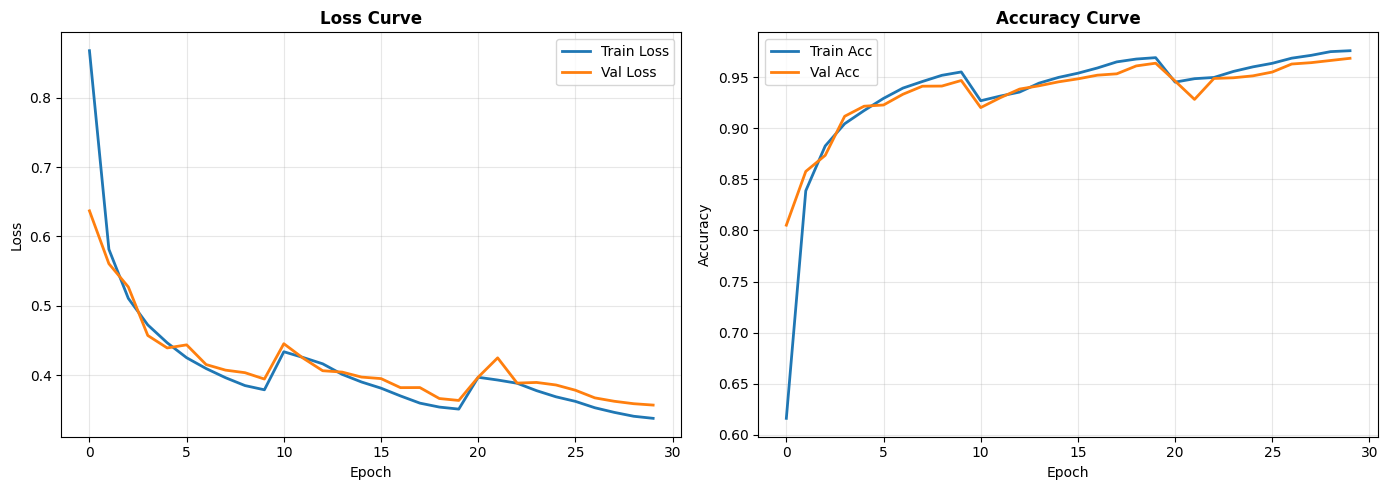

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val Acc',   linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Val Accuracy (best model): 0.9687


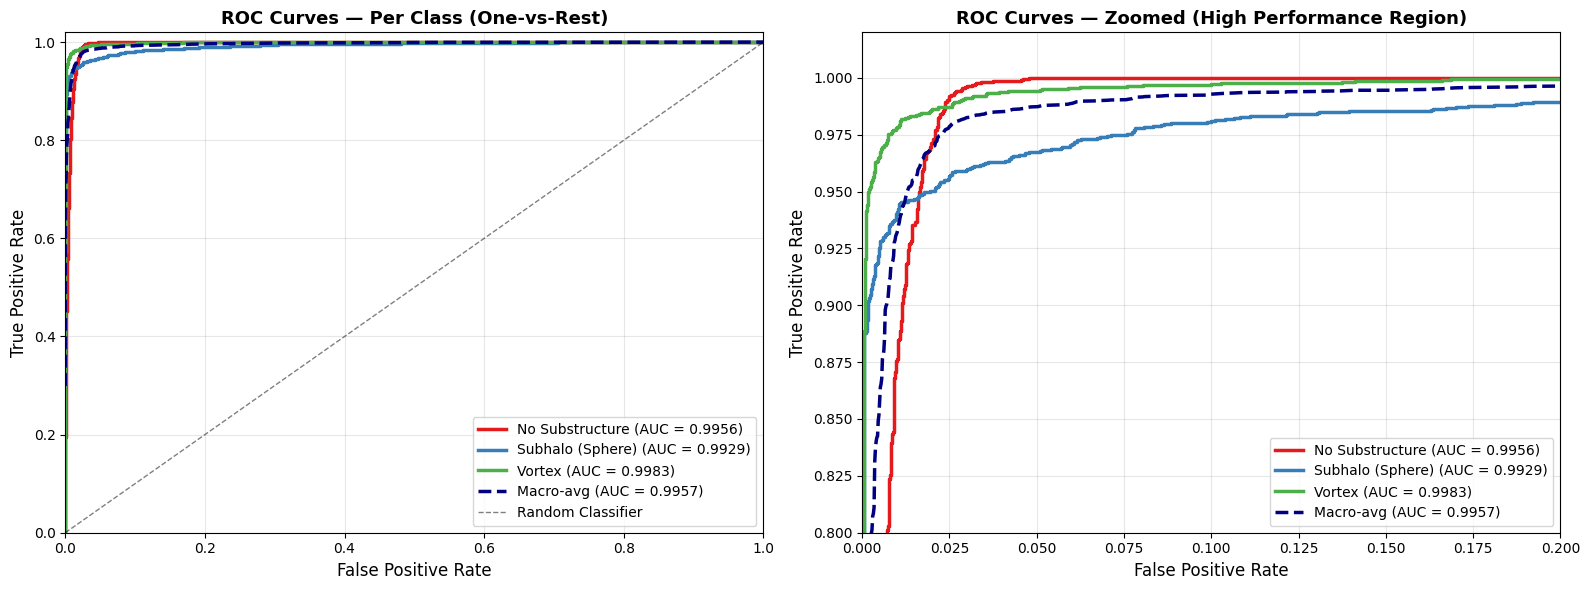


── AUC Scores ──────────────────────────────
  No Substructure          : 0.9956
  Subhalo (Sphere)         : 0.9929
  Vortex                   : 0.9983
  Macro-Average            : 0.9957


In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
_, val_acc, val_probs, val_labels = evaluate(model, val_loader, criterion, DEVICE)
print(f'Val Accuracy (best model): {val_acc:.4f}')

val_labels_bin = label_binarize(val_labels, classes=[0, 1, 2])

fpr, tpr, roc_auc = {}, {}, {}
for i, cls in enumerate(CLASS_NAMES):
    fpr[i], tpr[i], _ = roc_curve(val_labels_bin[:, i], val_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
fpr['macro'], tpr['macro'] = all_fpr, mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

COLORS = ['#e41a1c', '#377eb8', '#4daf4a']
CLASS_LABELS = ['No Substructure', 'Subhalo (Sphere)', 'Vortex']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, cls in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i], color=COLORS[i], lw=2.5,
            label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:.4f})')
ax.plot(fpr['macro'], tpr['macro'], color='navy', lw=2.5, linestyle='--',
        label=f'Macro-avg (AUC = {roc_auc["macro"]:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Per Class (One-vs-Rest)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

ax2 = axes[1]
for i, cls in enumerate(CLASS_NAMES):
    ax2.plot(fpr[i], tpr[i], color=COLORS[i], lw=2.5,
             label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:.4f})')
ax2.plot(fpr['macro'], tpr['macro'], color='navy', lw=2.5, linestyle='--',
         label=f'Macro-avg (AUC = {roc_auc["macro"]:.4f})')
ax2.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax2.set_xlim([0, 0.2]); ax2.set_ylim([0.8, 1.02])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curves — Zoomed (High Performance Region)', fontweight='bold', fontsize=13)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── AUC Scores ──────────────────────────────')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {CLASS_LABELS[i]:25s}: {roc_auc[i]:.4f}')
print(f'  {"Macro-Average":25s}: {roc_auc["macro"]:.4f}')

Classification Report:
                  precision    recall  f1-score   support

 No Substructure       0.94      1.00      0.97      2500
Subhalo (Sphere)       0.99      0.93      0.96      2500
          Vortex       0.98      0.98      0.98      2500

        accuracy                           0.97      7500
       macro avg       0.97      0.97      0.97      7500
    weighted avg       0.97      0.97      0.97      7500



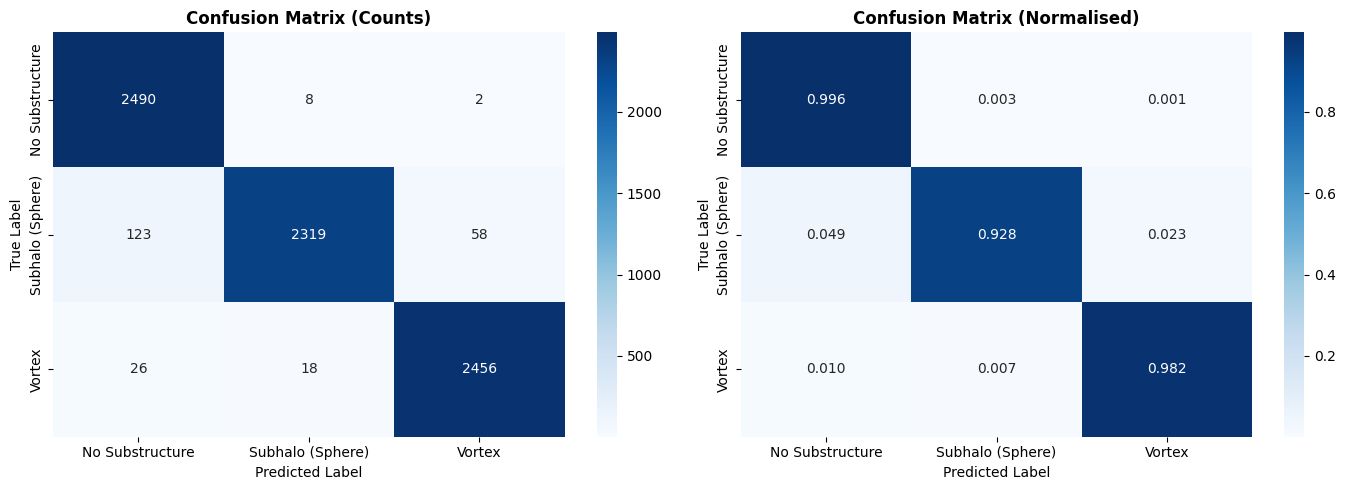

In [ ]:
val_preds = val_probs.argmax(axis=1)

print('Classification Report:')
print(classification_report(val_labels, val_preds, target_names=CLASS_LABELS))

cm = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=axes[1],
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

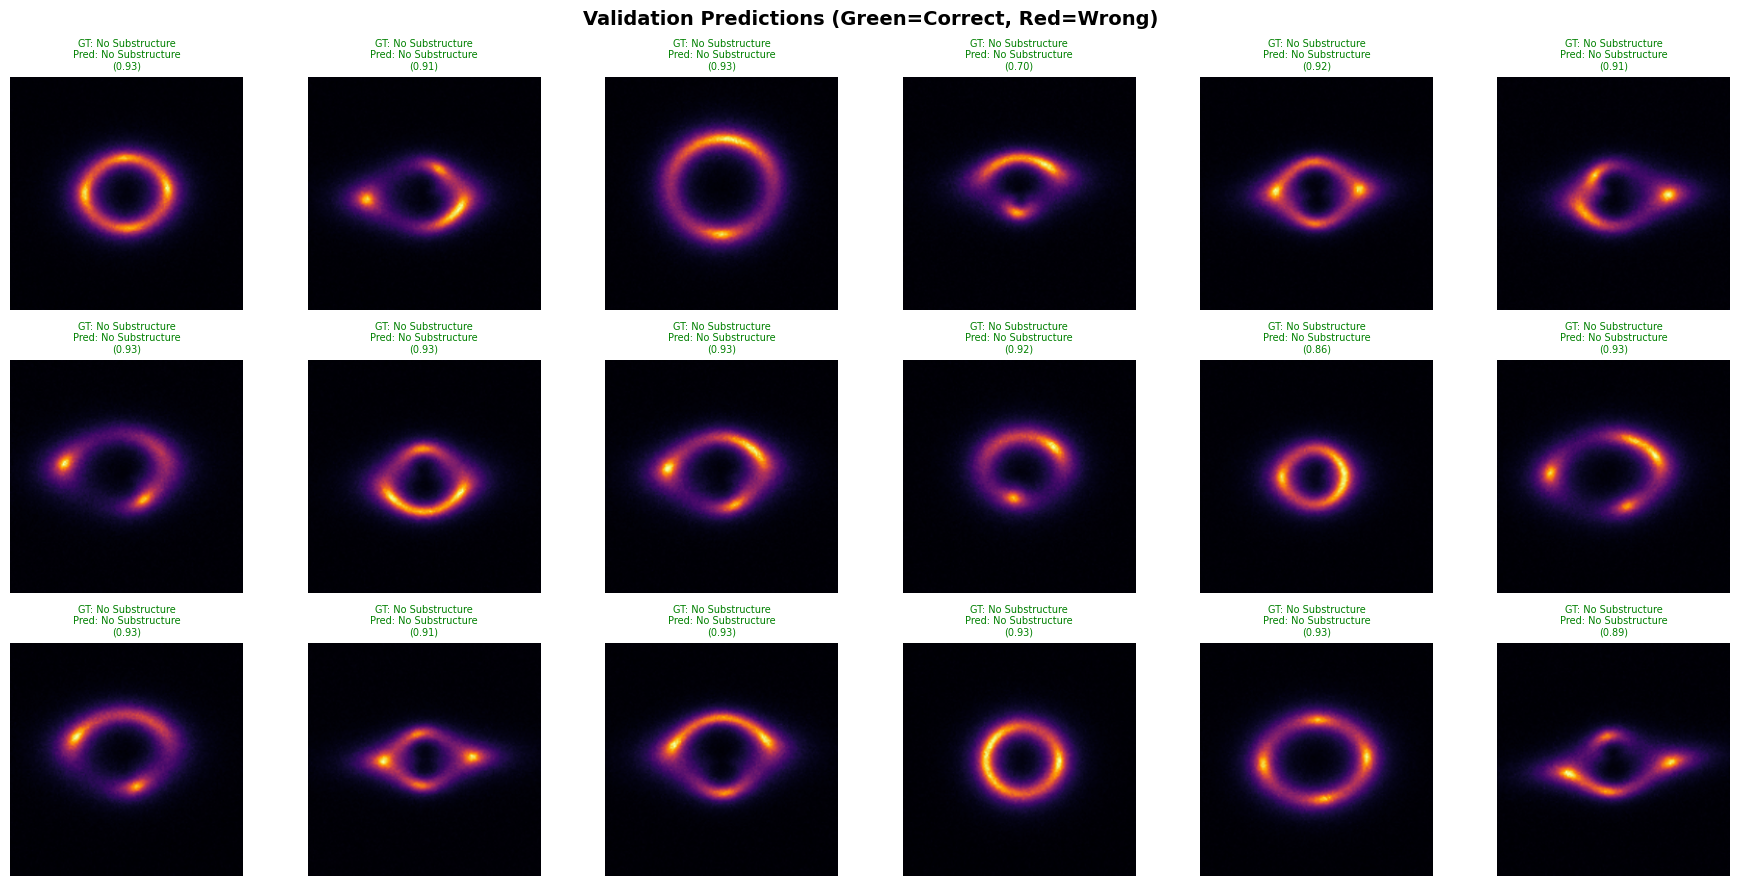

In [ ]:
model.eval()
imgs_batch, labels_batch = next(iter(val_loader))
imgs_batch = imgs_batch.to(DEVICE)

with torch.no_grad():
    logits = model(imgs_batch)
    probs  = F.softmax(logits, dim=1).cpu().numpy()
    preds  = probs.argmax(axis=1)

mean = np.array(IMAGENET_MEAN)[:, None, None]
std  = np.array(IMAGENET_STD)[:, None, None]

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Validation Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')

for i in range(18):
    ax = axes[i // 6][i % 6]
    img = imgs_batch[i].cpu().numpy()
    img = (img * std + mean).clip(0, 1)[0]   
    ax.imshow(img, cmap='inferno')
    correct = preds[i] == labels_batch[i].item()
    color   = 'green' if correct else 'red'
    ax.set_title(
        f'GT: {CLASS_LABELS[labels_batch[i]]}\nPred: {CLASS_LABELS[preds[i]]}\n({probs[i][preds[i]]:.2f})',
        fontsize=7, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
macro_auc = roc_auc_score(val_labels_bin, val_probs, average='macro')
weighted_auc = roc_auc_score(val_labels_bin, val_probs, average='weighted')

print('=' * 55)
print('  DEEPLENSE GSoC 2026 — Test I Final Results')
print('=' * 55)
print(f'  Model            : EfficientNet-B3 (pretrained)')
print(f'  Val Accuracy     : {val_acc:.4f}')
print(f'  Macro AUC        : {macro_auc:.4f}')
print(f'  Weighted AUC     : {weighted_auc:.4f}')
print()
for i, cls in enumerate(CLASS_LABELS):
    print(f'  AUC [{cls:20s}]: {roc_auc[i]:.4f}')
print('=' * 55)

  DEEPLENSE GSoC 2026 — Test I Final Results
  Model            : EfficientNet-B3 (pretrained)
  Val Accuracy     : 0.9687
  Macro AUC        : 0.9956
  Weighted AUC     : 0.9956

  AUC [No Substructure     ]: 0.9956
  AUC [Subhalo (Sphere)    ]: 0.9929
  AUC [Vortex              ]: 0.9983
